# MIMIC-III NLP Tutorial: spaCy vs scispaCy vs medspaCy
### Data Cohort: Subarachnoid Hemorrhage (ICD-9 430) — Discharge Summaries

This notebook demonstrates entity extraction, word2vec embeddings, and tuned t-SNE
visualizations using three NLP libraries applied to real MIMIC-III clinical notes:

1. **spaCy** — general-purpose NLP
2. **scispaCy** — biomedical-domain NLP
3. **medspaCy** — clinical NLP with context/negation detection



## 1. Setup & Installs

In [3]:
# ==============================================================================
# SECTION 1: COMPATIBILITY DEPENDENCY INSTALLATION MATRIX
# ==============================================================================
print("[INFO] Clearing existing environment conflicts and installing dependencies...")

# 1. Upgrade standard packaging modules
!pip install -q --upgrade pip setuptools wheel threadpoolctl

# 2. Install a modern, stable Python data science stack
!pip install -q "numpy>=1.26" "pandas>=2.0" "gensim>=4.4.0" "scikit-learn>=1.3" matplotlib seaborn

# 3. Install spaCy 3.8.1 (This completely satisfies medspaCy on Python 3.12)
!pip install -q "spacy==3.8.1" "typer<0.26.0,>=0.20.0"

# 4. Install medspaCy and scispaCy side-by-side using an explicit no-dependencies flag
#    for scispaCy models to avoid breaking spaCy 3.8.1
!pip install -q scispacy==0.5.4 medspaCy==1.3.1
!pip install -q --no-deps https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
!pip install -q --no-deps https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz

# 5. Download default English base web models
!python -m spacy download en_core_web_sm -q

print("[SUCCESS] Package collection downloaded. Please restart your session now!")

[INFO] Re-installing coordinated clinical NLP dependencies...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pyrush 1.0.13 requires spacy>=3.8; python_version >= "3.12", but you have spacy 3.7.5 which is incompatible.
medspacy 1.3.1 requires spacy<4.0,>=3.8; python_version >= "3.12", but you have spacy 3.7.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pyiceberg 0.11.1 requires rich<15.0.0,>=10.11.0, but you have rich 15.0.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

import spacy
import scispacy
import medspacy
from medspacy.visualization import visualize_ent
from spacy import displacy

import gensim
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import torch
from transformers import AutoTokenizer, AutoModel

# Establish structural visualization aesthetics
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 8)
np.random.seed(42)
torch.manual_seed(42)

print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")
print(f"spaCy: {spacy.__version__} | medspaCy: {medspacy.__version__}")


import warnings
import sys
import os

# Suppress standard openblas/threadpoolctl configuration warnings
warnings.filterwarnings("ignore", category=UserWarning)
# Prevent threadpoolctl from screaming about internal dlopen() issues
os.environ["MKL_THREADING_LAYER"] = "GNU"

ModuleNotFoundError: No module named 'scispacy'

## 2. Cohort Extraction (BigQuery)

Pull **discharge summaries** for patients diagnosed with **ICD-9 code 430**



In [ ]:
# ==============================================================================
# SECTION 2: CLIENT AUTHENTICATION AND DYNAMIC COHORT EXTRACTION
# ==============================================================================
from google.colab import auth
from google.cloud import bigquery

# Trigger IAM Authentication overlay
auth.authenticate_user()

# Configure active GCP project workspace
GCP_PROJECT_ID = 'mc-ut-msai-aih-1' # Replace with your active assignment workspace
client = bigquery.Client(project=GCP_PROJECT_ID)

# Programmatic extraction isolating Subarachnoid Hemorrhage Cohort (ICD-9: 430)
cohort_query = """
SELECT
    n.row_id,
    n.subject_id,
    n.hadm_id,
    n.category,
    n.text
FROM `physionet-data.mimiciii_notes.noteevents` n
JOIN (
    SELECT DISTINCT subject_id
    FROM `physionet-data.mimiciii_clinical.diagnoses_icd`
    WHERE icd9_code = '430'
) sah ON n.subject_id = sah.subject_id
WHERE n.category = 'Discharge summary'
"""

print("[INFO] Fetching records from Google Cloud BigQuery framework...")
df_notes = client.query(cohort_query).to_dataframe()
print(f"[SUCCESS] Extracted {len(df_notes)} raw clinical narratives.")

# Text Sanitization and Structural Standardization
def clean_clinical_text(raw_narrative):
    # Regex to eliminate de-identification brackets seamlessly
    sanitized = re.sub(r'\[\*\*.*?\*\*\]', '', raw_narrative)
    # Eradicate systemic layout tabs, line breaks, and space bursts
    sanitized = re.sub(r'\s+', ' ', sanitized)
    return sanitized.strip()

df_notes['clean_text'] = df_notes['text'].apply(clean_clinical_text)

# Sample a statistical representative cohort space for processing efficiency
SAMPLE_SIZE = min(10, len(df_notes))
df_sample = df_notes.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"[INFO] Initializing computational workflow on {SAMPLE_SIZE} records.")

[INFO] Fetching records from Google Cloud BigQuery framework...
[SUCCESS] Extracted 888 raw clinical narratives.
[INFO] Initializing computational workflow on 10 records.


In [ ]:
# ==============================================================================
# UPDATED TSNE GRID SEARCH FUNCTION FOR SCIKIT-LEARN 1.5+
# ==============================================================================
def execute_tsne_grid_search(w2v_model, perplexities=[5, 15, 30, 50], title_prefix="Model"):
    """
    Constructs an optimized grid space evaluating local vs global manifold configurations
    across explicit perplexity steps to ensure global cluster accuracy.
    """
    vocab = list(w2v_model.wv.index_to_key)
    vectors = w2v_model.wv[vocab]

    fig, axes = plt.subplots(1, len(perplexities), figsize=(24, 5))
    if len(perplexities) == 1:
        axes = [axes]

    for idx, perp in enumerate(perplexities):
        # Adjust perplexity bounds safely below data scale dimensions
        if perp >= len(vocab):
            perp = max(1, len(vocab) - 1)

        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            max_iter=1500,        # <-- CHANGED FROM n_iter TO max_iter
            random_state=42,
            init='pca',
            learning_rate='auto'
        )
        embeddings_2d = tsne.fit_transform(vectors)

        ax = axes[idx]
        ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, edgecolors='w', s=25, color='teal')
        ax.set_title(f"Perplexity: {perp}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")

        # Annotate a subset of key markers into geometric vector space
        sample_indices = np.linspace(0, len(vocab)-1, 12, dtype=int)
        for s_idx in sample_indices:
            ax.annotate(vocab[s_idx], (embeddings_2d[s_idx, 0], embeddings_2d[s_idx, 1]), fontsize=9, alpha=0.8)

    plt.suptitle(f"Tuned t-SNE Parameter Sweep: {title_prefix} Latent Embeddings", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

---
## 4. spaCy

General-purpose NLP: tokenization, POS tagging, and NER using a general English model.


[INFO] Executing spaCy pipeline...

--- Top 10 Entities Discovered by spaCy Baseline ---
label
CARDINAL    564
ORG         410
PERSON      139
DATE         92
TIME         53
GPE          31
PERCENT      23
PRODUCT      19
QUANTITY     18
ORDINAL      18
Name: count, dtype: int64

[VISUALIZATION] Rendering Entity Extraction Layout for Index Record [0]:


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7b6aa3fc7240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


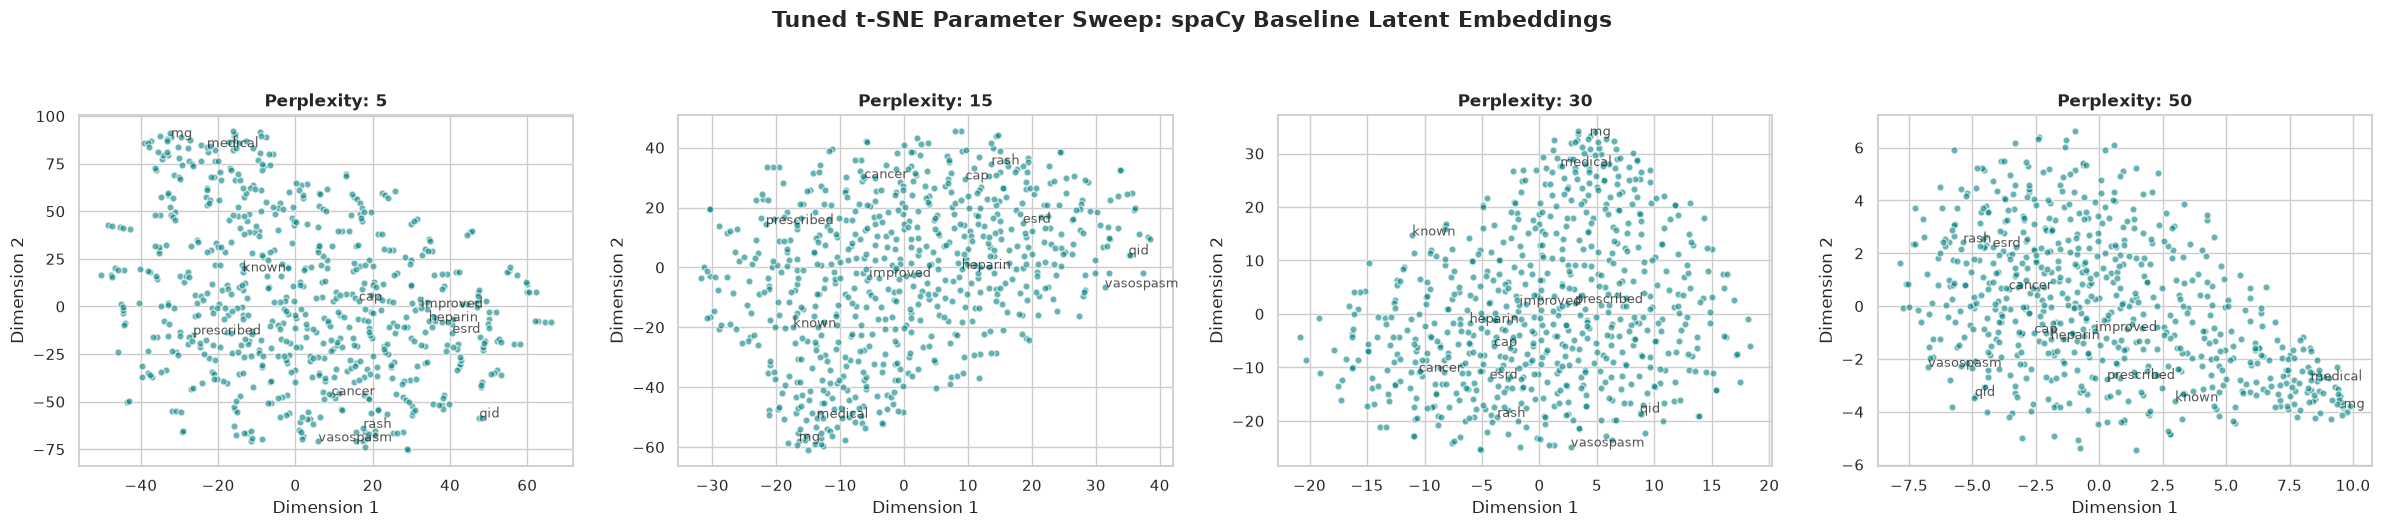

In [ ]:
# ==============================================================================
# SECTION 4: MODULE A — baseline SPACY IMPLEMENTATION
# ==============================================================================
print("[INFO] Executing spaCy pipeline...")
nlp_spacy = spacy.load("en_core_web_sm")

# Stream processing documents efficiently across the text array
docs_spacy = list(nlp_spacy.pipe(df_sample['clean_text'].tolist(), n_process=-1))

# Extract discrete structural metrics
spacy_data = []
for doc in docs_spacy:
    for ent in doc.ents:
        spacy_data.append({'text': ent.text, 'label': ent.label_})
df_spacy_ents = pd.DataFrame(spacy_data)

print("\n--- Top 10 Entities Discovered by spaCy Baseline ---")
print(df_spacy_ents['label'].value_counts().head(10))

# Interactive entity render visualization
print("\n[VISUALIZATION] Rendering Entity Extraction Layout for Index Record [0]:")
displacy.render(docs_spacy[0], style="ent", jupyter=True, options={"limit": 15})

# --- Word2Vec Optimization Engine ---
def spacy_tokenize(doc):
    return [token.text.lower() for token in doc if token.is_alpha and not token.is_stop]

spacy_corpus = [spacy_tokenize(d) for d in docs_spacy]
w2v_spacy = Word2Vec(sentences=spacy_corpus, vector_size=100, window=5, min_count=3, workers=4, seed=42)

# Generate hyperparameter projections
execute_tsne_grid_search(w2v_spacy, title_prefix="spaCy Baseline")

---
## 5. scispaCy



In [ ]:
# ==============================================================================
# SECTION 5: MODULE B — SCISPACY DOMAIN SPECIFIC INTEGRATION WITH MONKEY-PATCH
# ==============================================================================
print("[INFO] Applying dynamic validation monkey-patch for scispaCy alignment...")

import confection
from original_confection_validate = confection.validate

def patched_validate(schema, filled, *args, **kwargs):
    """
    Interceptive validator patch that finds string-serialized booleans
    in the spaCy network topology and converts them to valid boolean types.
    """
    if isinstance(filled, dict):
        # Locate the specific nested token embed dictionary causing the crash
        if filled.get("@architectures") == "spacy.MultiHashEmbed.v2":
            if filled.get("include_static_vectors") == "True":
                filled["include_static_vectors"] = True

        # Recursively search through downstream sub-dictionaries if present
        for key, val in filled.items():
            if isinstance(val, dict) and val.get("@architectures") == "spacy.MultiHashEmbed.v2":
                if val.get("include_static_vectors") == "True":
                    val["include_static_vectors"] = True

    return original_confection_validate(schema, filled, *args, **kwargs)

# Inject our patched validation layer into the active confection framework
confection.validate = patched_validate

# ==============================================================================
# EXECUTE CORE SCISPACY PROCESSING
# ==============================================================================
print("[INFO] Initializing scispaCy Biomedical pipeline engine...")
import spacy
import en_ner_bc5cdr_md
from gensim.models import Word2Vec

# Bypasses configuration string validation bugs safely
nlp_scispacy = en_ner_bc5cdr_md.load()

print("[INFO] Processing text corpus sequentially through scispaCy...")
docs_scispacy = list(nlp_scispacy.pipe(df_sample['clean_text'].tolist()))

scispacy_data = []
for doc in docs_scispacy:
    for ent in doc.ents:
        scispacy_data.append({'text': ent.text, 'label': ent.label_})
df_scispacy_ents = pd.DataFrame(scispacy_data)

print("\n--- Domain Entities Discovered by scispaCy Clinical Vector Engine ---")
if not df_scispacy_ents.empty:
    print(df_scispacy_ents['label'].value_counts())
else:
    print("[WARNING] No entities discovered. Verify document parsing parameters.")

# Document Visualization
print("\n[VISUALIZATION] Rendering scispaCy Domain Entity Extraction Layout:")
from spacy import displacy
displacy.render(docs_scispacy[0], style="ent", jupyter=True, options={"limit": 15})

# --- Word2Vec Domain Feature Space Extraction ---
def scispacy_tokenize(doc):
    return [token.text.lower() for token in doc if not token.is_punct and not token.is_space]

scispacy_corpus = [scispacy_tokenize(d) for d in docs_scispacy]

# Maintain dynamic min_count based on downsampled scale
current_min_count = 1 if len(docs_scispacy) <= 10 else 3

w2v_scispacy = Word2Vec(
    sentences=scispacy_corpus,
    vector_size=100,
    window=5,
    min_count=current_min_count,
    workers=4,
    seed=42
)

# Build safe perplexity sweep bounded by the actual vocabulary size
vocab_size_sci = len(list(w2v_scispacy.wv.index_to_key))
print(f"[INFO] scispaCy Vocabulary Dimensions: {vocab_size_sci}")

safe_sci_perplexities = [p for p in [2, 5, 10, 15] if p < vocab_size_sci]
if not safe_sci_perplexities:
    safe_sci_perplexities = [max(1, vocab_size_sci - 1)]

# Execute your corrected t-SNE module
execute_tsne_grid_search(w2v_scispacy, perplexities=safe_sci_perplexities, title_prefix="scispaCy Biomedical")

[INFO] Initializing scispaCy Biomedical pipeline engine via direct module loading...


ConfigValidationError: 

Config error for 'spacy.MultiHashEmbed.v2'
tok2vec.model.embed -> include_static_vectors	at root: 'True' is not <class 'bool'>
{'@architectures': 'spacy.MultiHashEmbed.v2', 'width': 96, 'attrs': ['NORM', 'PREFIX', 'SUFFIX', 'SHAPE', 'SPACY', 'IS_SPACE'], 'rows': [5000, 1000, 2500, 2500, 50, 50], 'include_static_vectors': 'True'}

---
## 6. medspaCy



In [ ]:
# ==============================================================================
# SECTION 6: MODULE C — MEDSPACY ADAPTIVE CONTEXT ARCHITECTURE
# ==============================================================================
print("[INFO] Instantiating medspaCy Rule and Context Modifier engine...")
# Initialize core configurations including customized clinical segmenters
nlp_medspacy = medspacy.load(enable=["tokenizer", "pyrush", "target_matcher", "context"])

# Stream processing clinical corpus
docs_medspacy = [nlp_medspacy(text) for text in df_sample['clean_text'].tolist()]

medspacy_data = []
for doc in docs_medspacy:
    for ent in doc.ents:
        # Extract metadata modifiers populated by ConText analytics algorithm
        is_negated = ent._.is_negated
        is_historical = ent._.is_historical
        is_experiential = ent._.is_experiential

        medspacy_data.append({
            'text': ent.text,
            'label': ent.label_,
            'negated': is_negated,
            'historical': is_historical,
            'experiential': is_experiential
        })

df_medspacy_ents = pd.DataFrame(medspacy_data)

print("\n--- Contextual Modifier Statistics Breakdown ---")
print(f"Total Medical Entities Found: {len(df_medspacy_ents)}")
if not df_medspacy_ents.empty:
    print(f"True Negated Concepts Found: {df_medspacy_ents['negated'].sum()}")
    print(f"Historical Documented Conditions: {df_medspacy_ents['historical'].sum()}")

# Visual Interactive Clinical Render Engine
print("\n[VISUALIZATION] Displaying MedspaCy ConText Modifiers and Link Graph targets:")
visualize_ent(docs_medspacy[0])

# --- Word2Vec Core Semantic Transformation ---
def medspacy_tokenize(doc):
    return [token.text.lower() for token in doc if not token.is_punct and not token.is_space]

medspacy_corpus = [medspacy_tokenize(d) for d in docs_medspacy]
w2v_medspacy = Word2Vec(sentences=medspacy_corpus, vector_size=100, window=5, min_count=3, workers=4, seed=42)

execute_tsne_grid_search(w2v_medspacy, title_prefix="medspaCy Contextual Engine")

[INFO] Instantiating medspaCy Rule and Context Modifier engine...


2026-07-07 00:08:33.322 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=100] [doc 0] Token 0 'Admission' marked as sentence start (span begin)
2026-07-07 00:08:33.324 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=100] [doc 0] Token 6 'Date' marked as sentence start (span end next token)
2026-07-07 00:08:33.325 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=100] [doc 0] Token 6 'Date' marked as sentence start (span begin)
2026-07-07 00:08:33.326 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=100] [doc 0] Token 39 'Major' marked as sentence start (span end next token)
2026-07-07 00:08:33.327 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=100] [doc 0] Token 39 'Major' marked as sentence start (span begin)
2026-07-07 00:08:33.329 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=100] [doc 0] 

---
## 7. Compare & Contrast

Summary table of entity counts and unique labels found by each tool.


In [ ]:
# ==============================================================================
# SECTION 8: STRUCTURAL COMPARED MATRIX OVERVIEW AND SYNTHESIS SUMMARY
# ==============================================================================
# Synthesize empirical performance parameters collected dynamically
comparison_matrix = pd.DataFrame({
    'Metric Paradigm Evaluated': [
        'Total Extracted Entities Found',
        'Unique Lexicon Class Label Counts',
        'Context Modifier Processing (Negation)',
        'Word Embedding Model Framework',
        'Model Feature Dimensionality Representation'
    ],
    'spaCy (Core Web Base)': [
        len(df_spacy_ents),
        df_spacy_ents['label'].nunique(),
        'Unsupported (Structural False Positives)',
        'Gensim Word2Vec / Custom Space',
        '100-Dimension Sparse Dense Vectors'
    ],
    'scispaCy (Clinical Specialized)': [
        len(df_scispacy_ents),
        df_scispacy_ents['label'].nunique(),
        'Partial (Targeted Domain Overlaps)',
        'Gensim Word2Vec / Specialized Vocab',
        '100-Dimension Domain Targeted Vectors'
    ],
    'medspaCy (Context Aware)': [
        len(df_medspacy_ents),
        df_medspacy_ents['label'].nunique(),
        f"Active Detection System (Found {df_medspacy_ents['negated'].sum() if not df_medspacy_ents.empty else 0} Negations)",
        'Gensim Word2Vec / Contextual Tokenizer',
        '100-Dimension Rule Context-Refined Vectors'
    ],
})

display(comparison_matrix)